In [20]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [12]:
df = np.round(pd.read_csv('50_Startups.csv')[['R&D Spend','Administration','Marketing Spend','Profit']]/10000)

np.random.seed(9)

df = df.sample(5)


In [13]:
# Remove Profit column
df = df.iloc[:,0:-1].copy()


In [14]:
print("Original Data:")
print(df)


Original Data:
    R&D Spend  Administration  Marketing Spend
21        8.0            15.0             30.0
37        4.0             5.0             20.0
2        15.0            10.0             41.0
14       12.0            16.0             26.0
44        2.0            15.0              3.0


In [15]:
# create missing values
df.iloc[1,0] = np.nan
df.iloc[3,1] = np.nan
df.iloc[-1,-1] = np.nan

print("\nData with Missing Values:")
print(df)



Data with Missing Values:
    R&D Spend  Administration  Marketing Spend
21        8.0            15.0             30.0
37        NaN             5.0             20.0
2        15.0            10.0             41.0
14       12.0             NaN             26.0
44        2.0            15.0              NaN


In [16]:
# 3. Initial Mean Imputation
# -----------------------------

df_iter = df.copy()

for col in df_iter.columns:
    df_iter[col] = df_iter[col].fillna(df_iter[col].mean())

print("\nInitial Mean Imputation:")
print(df_iter)


Initial Mean Imputation:
    R&D Spend  Administration  Marketing Spend
21       8.00           15.00            30.00
37       9.25            5.00            20.00
2       15.00           10.00            41.00
14      12.00           11.25            26.00
44       2.00           15.00            29.25


In [17]:
# MICE Iterations  
lr = LinearRegression()

iterations = 100

for i in range(iterations):

    # Predict R&D Spend
    X = df_iter.iloc[[0,2,3,4],1:3]
    y = df_iter.iloc[[0,2,3,4],0]

    lr.fit(X,y)
    df_iter.iloc[1,0] = lr.predict(df_iter.iloc[1,1:].values.reshape(1,2))[0]


    # Predict Administration
    X = df_iter.iloc[[0,1,2,4],[0,2]]
    y = df_iter.iloc[[0,1,2,4],1]

    lr.fit(X,y)
    df_iter.iloc[3,1] = lr.predict(df_iter.iloc[3,[0,2]].values.reshape(1,2))[0]


    # Predict Marketing Spend
    X = df_iter.iloc[0:4,0:2]
    y = df_iter.iloc[0:4,2]

    lr.fit(X,y)
    df_iter.iloc[-1,-1] = lr.predict(df_iter.iloc[-1,0:2].values.reshape(1,2))[0]

C:\Users\ASUS\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\ASUS\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\ASUS\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\ASUS\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\ASUS\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\ASUS\miniconda3\

In [18]:
print("\nFinal Data after 100 MICE Iterations:")
print(df_iter)


Final Data after 100 MICE Iterations:
    R&D Spend  Administration  Marketing Spend
21   8.000000       15.000000        30.000000
37  26.718364        5.000000        20.000000
2   15.000000       10.000000        41.000000
14  12.000000       13.022368        26.000000
44   2.000000       15.000000        70.692067


In [21]:
#using sklearn 
df = pd.read_csv("50_Startups.csv")

df = df[['R&D Spend','Administration','Marketing Spend']].copy()

# Create missing values
df.iloc[1,0] = np.nan
df.iloc[3,1] = np.nan
df.iloc[-1,-1] = np.nan

print("Before Imputation:")
print(df)

# Apply MICE
imputer = IterativeImputer(max_iter=100, random_state=0)

df_imputed = imputer.fit_transform(df)

df_imputed = pd.DataFrame(df_imputed, columns=df.columns)

print("\nAfter MICE:")
print(df_imputed)

Before Imputation:
    R&D Spend  Administration  Marketing Spend
0   165349.20       136897.80        471784.10
1         NaN       151377.59        443898.53
2   153441.51       101145.55        407934.54
3   144372.41             NaN        383199.62
4   142107.34        91391.77        366168.42
5   131876.90        99814.71        362861.36
6   134615.46       147198.87        127716.82
7   130298.13       145530.06        323876.68
8   120542.52       148718.95        311613.29
9   123334.88       108679.17        304981.62
10  101913.08       110594.11        229160.95
11  100671.96        91790.61        249744.55
12   93863.75       127320.38        249839.44
13   91992.39       135495.07        252664.93
14  119943.24       156547.42        256512.92
15  114523.61       122616.84        261776.23
16   78013.11       121597.55        264346.06
17   94657.16       145077.58        282574.31
18   91749.16       114175.79        294919.57
19   86419.70       153514.11            

In [22]:
df_before = df.copy()

In [23]:
df_after = df_imputed

In [24]:
comparison = pd.concat([df_before, df_after], axis=1, keys=["Before", "After"])
print(comparison)

       Before                                         After                 \
    R&D Spend Administration Marketing Spend      R&D Spend Administration   
0   165349.20      136897.80       471784.10  165349.200000   136897.80000   
1         NaN      151377.59       443898.53  145589.400007   151377.59000   
2   153441.51      101145.55       407934.54  153441.510000   101145.55000   
3   144372.41            NaN       383199.62  144372.410000   126706.03142   
4   142107.34       91391.77       366168.42  142107.340000    91391.77000   
5   131876.90       99814.71       362861.36  131876.900000    99814.71000   
6   134615.46      147198.87       127716.82  134615.460000   147198.87000   
7   130298.13      145530.06       323876.68  130298.130000   145530.06000   
8   120542.52      148718.95       311613.29  120542.520000   148718.95000   
9   123334.88      108679.17       304981.62  123334.880000   108679.17000   
10  101913.08      110594.11       229160.95  101913.080000   11

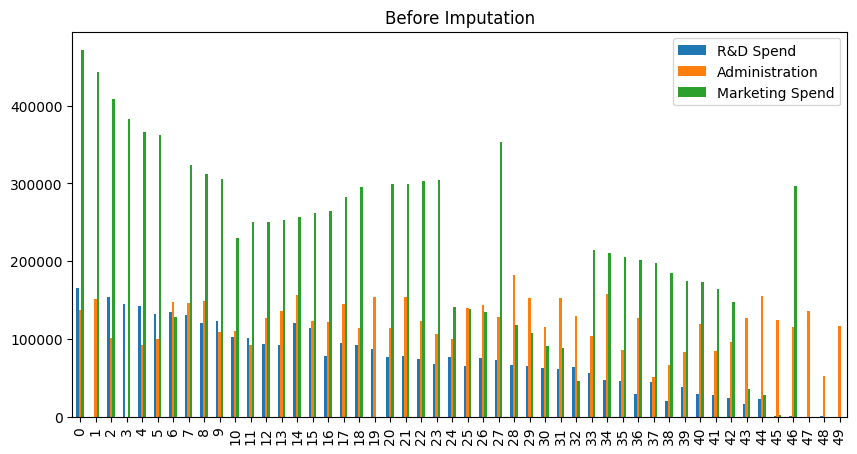

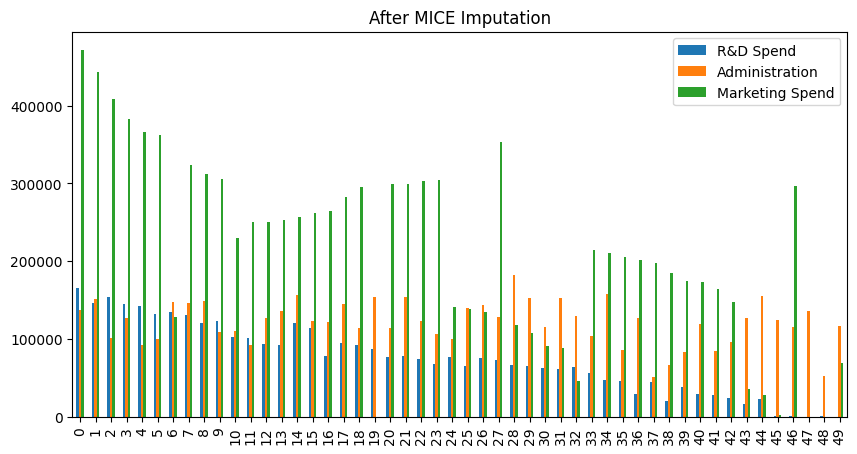

In [25]:
import matplotlib.pyplot as plt

df_before.plot(kind='bar', figsize=(10,5), title="Before Imputation")

plt.show()

df_after.plot(kind='bar', figsize=(10,5), title="After MICE Imputation")

plt.show()

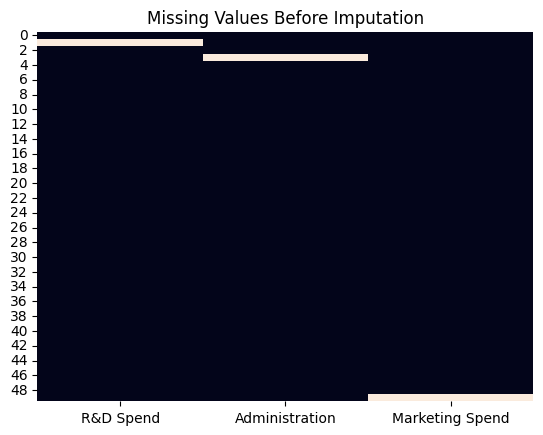

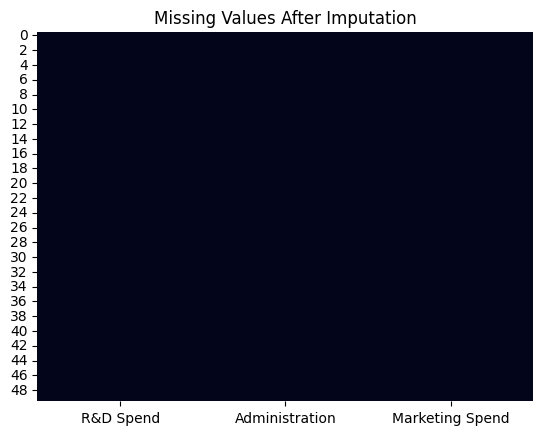

In [26]:
import seaborn as sns

sns.heatmap(df_before.isnull(), cbar=False)
plt.title("Missing Values Before Imputation")
plt.show()

sns.heatmap(df_after.isnull(), cbar=False)
plt.title("Missing Values After Imputation")
plt.show()

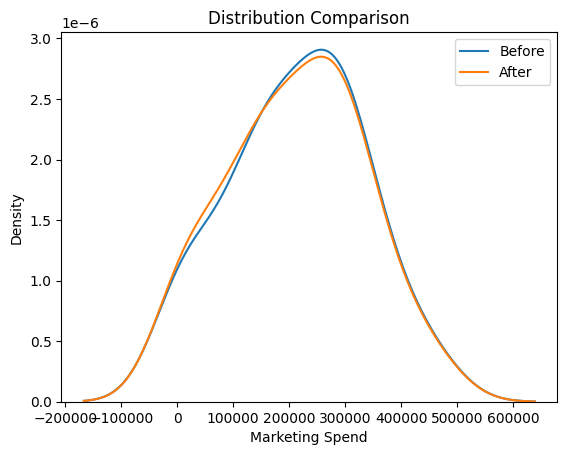

In [27]:
import seaborn as sns

sns.kdeplot(df_before['Marketing Spend'], label="Before")
sns.kdeplot(df_after['Marketing Spend'], label="After")

plt.legend()
plt.title("Distribution Comparison")
plt.show()